In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

I0000 00:00:1777361195.217525  131108 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777361197.951301  131108 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
file_path = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/consolidated_full.csv"
df=pd.read_csv(file_path)


In [4]:
df.shape

(265541, 26)

In [5]:
df.isnull().sum()

datetime_utc                             0
generation                             342
consumption                            359
wind_onshore                           343
temperature_c                        87896
humidity_percent                     87896
cloud_cover_percent                  87900
shortwave_radiation_wm2              87900
wind_speed_ms                        87896
ttf_gas                               6522
price                                  393
generation_renewable                   342
generation_non_renewable               342
wti_oil                                437
brent_oil                              437
natural_gas                            437
temperature_c_observed                 371
humidity_percent_observed              371
cloud_cover_percent_observed           371
shortwave_radiation_wm2_observed       371
wind_speed_ms_observed                 371
temperature_c_forecast              265178
humidity_percent_forecast           265178
cloud_cover

In [6]:
df.keys()

Index(['datetime_utc', 'generation', 'consumption', 'wind_onshore',
       'temperature_c', 'humidity_percent', 'cloud_cover_percent',
       'shortwave_radiation_wm2', 'wind_speed_ms', 'ttf_gas', 'price',
       'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed',
       'temperature_c_forecast', 'humidity_percent_forecast',
       'cloud_cover_percent_forecast', 'shortwave_radiation_wm2_forecast',
       'wind_speed_ms_forecast'],
      dtype='object')

In [7]:
data = df.drop(columns = ['temperature_c', 'humidity_percent', 'cloud_cover_percent',
       'shortwave_radiation_wm2', 'wind_speed_ms', 'temperature_c_forecast', 'humidity_percent_forecast',
       'cloud_cover_percent_forecast', 'shortwave_radiation_wm2_forecast',
       'wind_speed_ms_forecast'])

In [8]:
data.head(5)

,datetime_utc,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
0,2018-09-30 22:00:00+00:00,51434.81,NaN,4292.89,NaN,49.30,11863.35,28945.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-09-30 22:15:00+00:00,52085.57,NaN,4239.07,NaN,44.38,11809.11,29001.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-09-30 22:30:00+00:00,52345.33,NaN,4208.44,NaN,36.99,11632.71,29136.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-09-30 22:45:00+00:00,52902.03,NaN,4153.52,NaN,35.54,11937.48,28929.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-09-30 23:00:00+00:00,52799.83,42354.46,4047.26,NaN,46.50,12005.45,28880.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
data.isnull().sum()

datetime_utc                           0
generation                           342
consumption                          359
wind_onshore                         343
ttf_gas                             6522
price                                393
generation_renewable                 342
generation_non_renewable             342
wti_oil                              437
brent_oil                            437
natural_gas                          437
temperature_c_observed               371
humidity_percent_observed            371
cloud_cover_percent_observed         371
shortwave_radiation_wm2_observed     371
wind_speed_ms_observed               371
dtype: int64

In [10]:
data.keys()

Index(['datetime_utc', 'generation', 'consumption', 'wind_onshore', 'ttf_gas',
       'price', 'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'],
      dtype='object')

 # ***Selecting data only from last one year***

In [11]:
data["datetime_utc"] = pd.to_datetime(data["datetime_utc"], utc=True)

start_date = pd.Timestamp("2025-02-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-02-01 00:00:00", tz="UTC")

data = data[
    (data["datetime_utc"] >= start_date) &
    (data["datetime_utc"] <= end_date)
]

In [12]:
data.tail()

,datetime_utc,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
257284,2026-01-31 23:00:00+00:00,55732.36233,51641.31842,14644.42952,39.285,110.19,26734.05528,28722.69065,65.209999,70.690002,4.354,-2.400,97.079660,100.0,0.0,9.906544
257285,2026-01-31 23:15:00+00:00,55150.03397,50830.25718,14331.58355,39.285,95.14,26608.13671,28119.43306,65.209999,70.690002,4.354,-2.525,96.717320,100.0,0.0,9.199272
257286,2026-01-31 23:30:00+00:00,54411.85230,50287.21018,14160.32318,39.285,104.76,26335.74264,27619.46746,65.209999,70.690002,4.354,-2.650,96.354996,100.0,0.0,8.492001
257287,2026-01-31 23:45:00+00:00,54086.24809,49758.64134,13969.78983,39.285,95.89,26146.36708,27237.10131,65.209999,70.690002,4.354,-2.775,95.992660,100.0,0.0,7.784729
257288,2026-02-01 00:00:00+00:00,53869.80352,49125.44241,13968.65700,39.285,100.20,26089.38712,27100.08260,65.209999,70.690002,4.354,-2.900,95.630325,100.0,0.0,7.077457


# Preprocessing and cleaning #


1. Market data → step-like → ffill
2. Weather → smooth physics → interpolation
3. Observed weather → high-trust → preserve with ffill
4. Generation/consumption → continuous signals → interpolate
5. Solar → respects day/night physics
6. Target (price) → never fabricate

In [13]:
# Ensuring datetime as index
data['datetime_utc'] = pd.to_datetime(data['datetime_utc'])
data = data.set_index('datetime_utc').sort_index()

# -----------------------------
# 1. Defining column groups
# -----------------------------
weather_cols = [
    'temperature_c_observed', 'humidity_percent_observed',
    'cloud_cover_percent_observed',
    'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'
]

market_cols = [
    'ttf_gas', 'wti_oil', 'brent_oil', 'natural_gas'
]

core_cols = ['generation', 'consumption']
mix_cols = ['generation_renewable', 'generation_non_renewable']

# -----------------------------
# 2. Market variables → forward fill
# -----------------------------
data[market_cols] = data[market_cols].ffill()

# -----------------------------
# 3. Weather variables → time interpolation
# -----------------------------
data[weather_cols] = data[weather_cols].ffill().interpolate(method='time')

# -----------------------------
# 4. Core system variables → interpolate + ffill
# -----------------------------
data[core_cols] = data[core_cols].interpolate().ffill()

# -----------------------------
# 5. Energy mix → interpolate
# -----------------------------
data[mix_cols] = data[mix_cols].interpolate()

# -----------------------------
# 6. Wind generation → interpolate + light smoothing
# -----------------------------
data['wind_onshore'] = (
    data['wind_onshore']
    .interpolate()
    .rolling(3, min_periods=1)
    .mean()
)

# -----------------------------
# 7. Solar radiation (physics-aware)
# -----------------------------
# Nighttime → 0
night_mask = (data.index.hour < 6) | (data.index.hour > 20)
data.loc[night_mask, 'shortwave_radiation_wm2_observed'] = \
    data.loc[night_mask, 'shortwave_radiation_wm2_observed'].fillna(0)

# Daytime → interpolate
data['shortwave_radiation_wm2_observed'] = data['shortwave_radiation_wm2_observed'].interpolate()

# -----------------------------
# 8. Target variable →  NOT IMPUTING ANY VALUES
# -----------------------------
data = data[data['price'].notna()]

# -----------------------------
# 9. Final fallback (rare cases)
# -----------------------------
data = data.fillna(data.mean())

# -----------------------------
# 10. Making data for 15 mins interval
# -----------------------------
data = data.asfreq('15min')

In [14]:
data.head()

,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
datetime_utc,,,,,,,,,,,,,,,
2025-02-01 00:00:00+00:00,43647.56,49590.034,6718.130000,53.237,145.16,13764.33,28316.47,72.529999,76.760002,3.044,-4.2,93.088250,0.00,0.0,3.244996
2025-02-01 00:15:00+00:00,42999.59,49284.771,6684.440000,53.237,130.90,13693.32,28107.40,72.529999,76.760002,3.044,-4.0,92.665380,0.75,0.0,3.204023
2025-02-01 00:30:00+00:00,42356.21,48936.994,6634.916667,53.237,126.30,13590.71,27926.22,72.529999,76.760002,3.044,-3.8,92.242510,1.50,0.0,3.163050
2025-02-01 00:45:00+00:00,42885.89,48774.808,6519.993333,53.237,120.70,13451.72,27967.99,72.529999,76.760002,3.044,-3.6,91.819640,2.25,0.0,3.122077
2025-02-01 01:00:00+00:00,42428.46,48611.645,6402.266667,53.237,131.50,13272.07,27606.37,72.529999,76.760002,3.044,-3.4,91.396774,3.00,0.0,3.081104


In [15]:
data.isnull().sum()

generation                          0
consumption                         0
wind_onshore                        0
ttf_gas                             0
price                               0
generation_renewable                0
generation_non_renewable            0
wti_oil                             0
brent_oil                           0
natural_gas                         0
temperature_c_observed              0
humidity_percent_observed           0
cloud_cover_percent_observed        0
shortwave_radiation_wm2_observed    0
wind_speed_ms_observed              0
dtype: int64

In [16]:
#data[data.isna().all(axis=1)]

In [17]:
data.index.to_series().diff().value_counts()

datetime_utc
0 days 00:15:00    35040
Name: count, dtype: int64

In [18]:
data.keys()

Index(['generation', 'consumption', 'wind_onshore', 'ttf_gas', 'price',
       'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'],
      dtype='object')

In [19]:
##creating lags
for lag in [1,4,8,24,96,192,672,1344]:
    data[f"price_lag_{lag}"] = data["price"].shift(lag)

In [20]:
##creating rolling windows by mean:
windows = [1, 4, 8, 24, 96, 192, 672, 1344]

for win in windows:
    data[f'price_roll_mean_{win}'] = (
        data['price']
        .shift(1)              # IMPORTANT: avoid leakage
        .rolling(win)
        .mean()
    )

In [21]:
##creating rolling windows by standard:
windows = [1, 4, 8, 24, 96, 192, 672, 1344]

for win in windows:
    data[f'price_roll_std_{win}'] = (
        data['price']
        .shift(1)              
        .rolling(win)
        .std()
    )

In [22]:
data.keys()

Index(['generation', 'consumption', 'wind_onshore', 'ttf_gas', 'price',
       'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed',
       'price_lag_1', 'price_lag_4', 'price_lag_8', 'price_lag_24',
       'price_lag_96', 'price_lag_192', 'price_lag_672', 'price_lag_1344',
       'price_roll_mean_1', 'price_roll_mean_4', 'price_roll_mean_8',
       'price_roll_mean_24', 'price_roll_mean_96', 'price_roll_mean_192',
       'price_roll_mean_672', 'price_roll_mean_1344', 'price_roll_std_1',
       'price_roll_std_4', 'price_roll_std_8', 'price_roll_std_24',
       'price_roll_std_96', 'price_roll_std_192', 'price_roll_std_672',
       'price_roll_std_1344'],
      dtype='object')

In [23]:
data = data.dropna(subset=['price'])

In [24]:
## Data set for XG Boost

X = data.drop(columns=['price'])
y = data['price']

**Training XG Boost model and getting predictions from it**

In [25]:
split = int(len(data) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

**Training LSTM model and getting predictions from it**

In [26]:
scaler = StandardScaler()
scaled = scaler.fit_transform(data[['price']])

In [27]:
def create_sequences(data, window=96):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 96  # 1 day

X_seq, y_seq = create_sequences(scaled, window)

In [28]:
split = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

In [41]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


/home/home/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


394/394 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - loss: 0.2841 - val_loss: 0.0596
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - loss: 0.2346 - val_loss: 0.0603
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - loss: 0.2214 - val_loss: 0.0773
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - loss: 0.1976 - val_loss: 0.0712
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - loss: 0.1740 - val_loss: 0.0708
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - loss: 0.1572 - val_loss: 0.0713
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - loss: 0.1439 - val_loss: 0.0616
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - loss: 0.1298 - val_loss: 0.0608
Epoch 9/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - loss: 0.1234 - val_loss: 0.0560
Epoch 10/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - loss: 0.1192 - val_loss: 0.0559
Epoch 11/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - loss: 0.1150 - val_loss: 0.0612
Epoch 12/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 

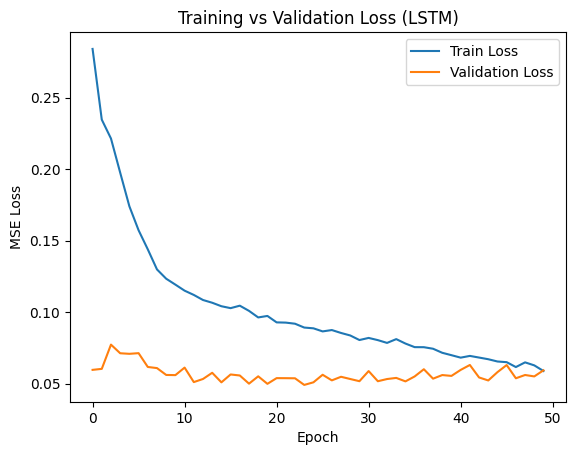

In [42]:
##Ploting Training vs Validation

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss (LSTM)')
plt.legend()
plt.show()

In [43]:
test_loss = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print("Test MSE:", test_loss)

Test MSE: 0.12483611702919006


In [44]:
##predicting with lstm
lstm_pred = model.predict(X_test_seq)

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


In [45]:
##Reverse scaling
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_lstm = scaler.inverse_transform(y_test_seq)


In [46]:
mae = mean_absolute_error(y_test_lstm, lstm_pred)
print("Test MAE:", mae)

Test MAE: 9.961946073620256


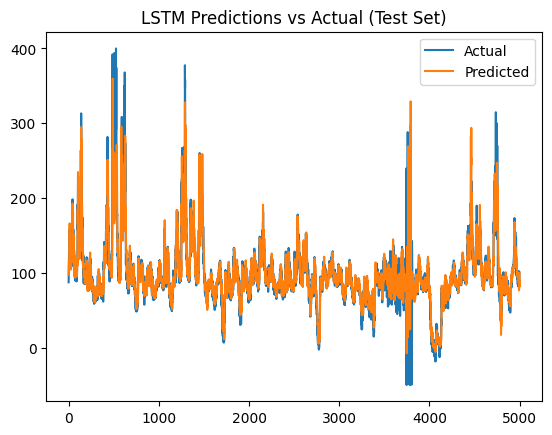

In [56]:
plt.figure
plt.plot(y_test_lstm[:5000], label='Actual')
plt.plot(lstm_pred[:5000], label='Predicted')
plt.title('LSTM Predictions vs Actual (Test Set)')
plt.legend()
plt.show()

In [53]:
time_index = data.index[-len(y_test_lstm):]
time_index = time_index[:5000]

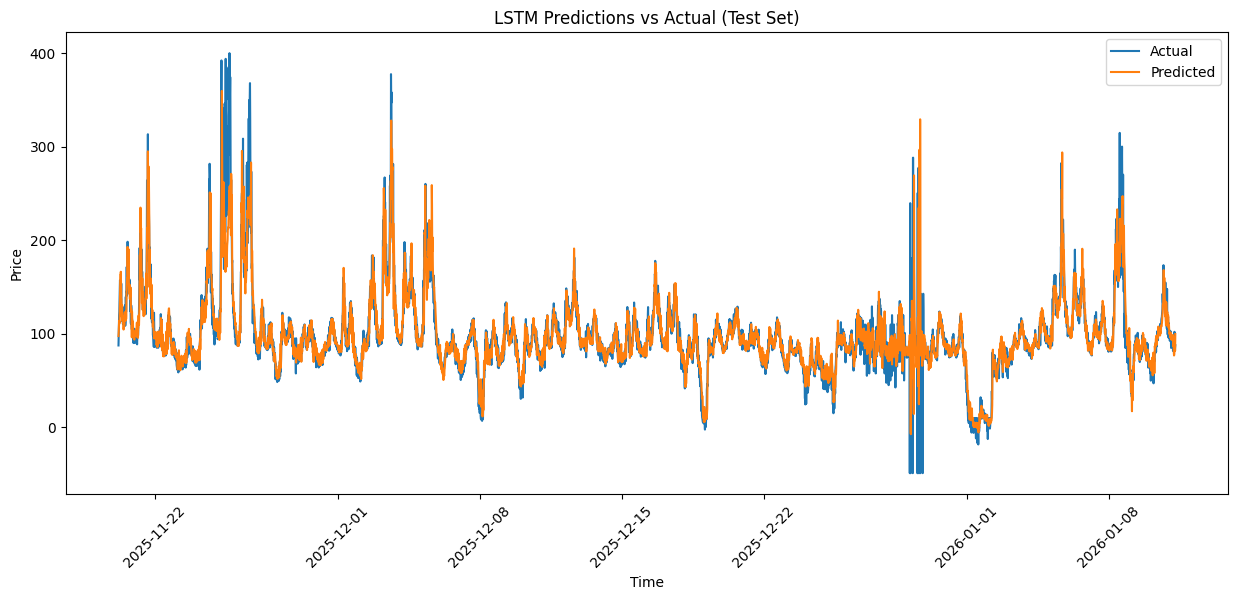

In [54]:
plt.figure(figsize=(15,6))

plt.plot(time_index, y_test_lstm[:5000], label='Actual')
plt.plot(time_index, lstm_pred[:5000], label='Predicted')

plt.title('LSTM Predictions vs Actual (Test Set)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [32]:
##Align predictions
xgb_pred = xgb_pred[-len(lstm_pred):]

In [33]:
#pred_av = 0.5 * xgb_pred + 0.5 * lstm_pred.flatten()
#pred_70_30 = 0.7 * xgb_pred + 0.3 * lstm_pred.flatten()

In [34]:
meta_X = np.column_stack([xgb_pred, lstm_pred.flatten()])

from sklearn.linear_model import Ridge

meta_model = Ridge()
meta_model.fit(meta_X, y_test[:len(meta_X)])

final_pred = meta_model.predict(meta_X)

In [35]:
mae_xgb = mean_absolute_error(y_test[:len(xgb_pred)], xgb_pred)
mae_lstm = mean_absolute_error(y_test_lstm, lstm_pred)
mae_ens = mean_absolute_error(y_test_lstm[:len(final_pred)], final_pred)

print("XGBoost MAE:", mae_xgb)
print("LSTM MAE:", mae_lstm)
print("Ensemble MAE:", mae_ens)

XGBoost MAE: 28.05797700230392
LSTM MAE: 9.643310023047311
Ensemble MAE: 14.767178611717164


# Comments

LSTM is overfitting, most probably.